#Fase 1 — Preparação
1. Baixar e extrair o dataset escolhido
2. Criar uma lista com os caminhos completos de todas as imagens (2.000 imagens)
3. Criar uma pasta de saída para as imagens processadas
4. Importar bibliotecas:
import cv2
import numpy as np
import os
import time
import matplotlib.pyplot as plt
from multiprocessing import Pool, cpu_count

In [ ]:
#INTALACAO BIB NECESSARIAS
!pip install opencv-python-headless -q
!pip install kaggle -q

In [ ]:
#IMPORTA BIB NECESSARIAS
import cv2
import numpy as np
import os
import time
import random
import matplotlib.pyplot as plt
import pandas as pd
from multiprocessing import Pool, cpu_count

In [ ]:
#DOWNLOAD DO DATASET EUROSAT

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d apollo2506/eurosat-dataset
!unzip -q eurosat-dataset.zip -d eurosat_raw
print('Download e extração concluídos!')

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/apollo2506/eurosat-dataset
License(s): CC0-1.0
100% 2.04G/2.04G [00:22<00:00, 97.5MB/s]

Download e extração concluídos!


In [ ]:
#DEBUG CLASSES
!ls eurosat_raw/EuroSAT/

AnnualCrop	      Highway	      Pasture	     River     train.csv
Forest		      Industrial      PermanentCrop  SeaLake   validation.csv
HerbaceousVegetation  label_map.json  Residential    test.csv


In [ ]:
#LISTA DAS CLASSES
pasta_raiz = 'eurosat_raw/EuroSAT'

classes = sorted([d for d in os.listdir(pasta_raiz)
    if os.path.isdir(os.path.join(pasta_raiz, d))])
print(f'Pasta raiz: {pasta_raiz}')
print(f'Classes encontradas ({len(classes)}): {classes}')

Pasta raiz: eurosat_raw/EuroSAT
Classes encontradas (10): ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


In [ ]:
#CONTAGEM DE IMGS POR CLASSES
extensoes_validas = ('.jpg', '.jpeg', '.png', '.tif', '.tiff')
todos_os_caminhos = []

for classe in classes:
    pasta_classe = os.path.join(pasta_raiz, classe)
    for arquivo in os.listdir(pasta_classe):
        if arquivo.lower().endswith(extensoes_validas):
            todos_os_caminhos.append(os.path.join(pasta_classe, arquivo))

print(f'Total de imagens encontradas: {len(todos_os_caminhos)}')

contagem_por_classe = {}
for caminho in todos_os_caminhos:
    classe = os.path.basename(os.path.dirname(caminho))
    contagem_por_classe[classe] = contagem_por_classe.get(classe, 0) + 1

print('\nDistribuição por classe:')
for cls, count in sorted(contagem_por_classe.items()):
    print(f'  {cls}: {count} imagens')

Total de imagens encontradas: 27000

Distribuição por classe:
  AnnualCrop: 3000 imagens
  Forest: 3000 imagens
  HerbaceousVegetation: 3000 imagens
  Highway: 2500 imagens
  Industrial: 2500 imagens
  Pasture: 2000 imagens
  PermanentCrop: 2500 imagens
  Residential: 3000 imagens
  River: 2500 imagens
  SeaLake: 3000 imagens


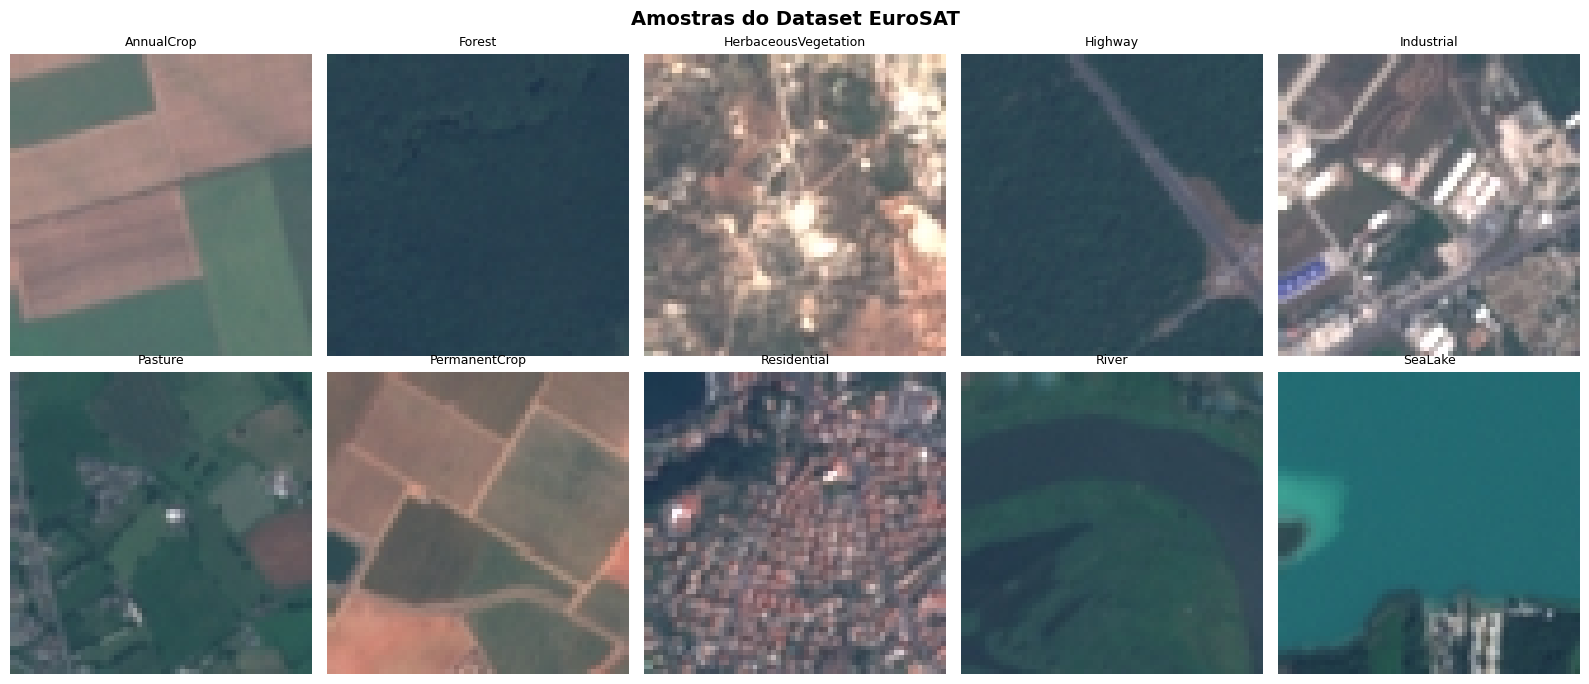

Figura salva como amostras_eurosat.png


In [ ]:
#VISUALIZACAO

caminhos_por_classe = {classe: [] for classe in classes}
for caminho in todos_os_caminhos:
    classe = os.path.basename(os.path.dirname(caminho))
    caminhos_por_classe[classe].append(caminho)

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
fig.suptitle('Amostras do Dataset EuroSAT', fontsize=14, fontweight='bold')

random.seed(42)
amostras = [random.choice(caminhos_por_classe[c]) for c in classes[:10]]

for ax, caminho in zip(axes.flatten(), amostras):
    img = cv2.imread(caminho)
    if img is None:
        print(f"Aviso: Não foi possível carregar a imagem em {caminho}. Pulando.")
        ax.set_title(f"Falha ao carregar: {os.path.basename(os.path.dirname(caminho))}", fontsize=9)
        ax.axis('off')
        continue
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    classe = os.path.basename(os.path.dirname(caminho))
    ax.imshow(img_rgb)
    ax.set_title(classe, fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.savefig('amostras_eurosat.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura salva como amostras_eurosat.png')

In [ ]:
#SELECAO 2000 IMGS

TOTAL_IMAGENS = 2000
random.seed(42)

lista_selecionada = []
n_por_classe = TOTAL_IMAGENS // len(classes)

for classe, caminhos in caminhos_por_classe.items():
    amostrados = random.sample(caminhos, min(n_por_classe, len(caminhos)))
    lista_selecionada.extend(amostrados)

random.shuffle(lista_selecionada)
lista_de_caminhos = lista_selecionada[:TOTAL_IMAGENS]

print(f'Imagens selecionadas: {len(lista_de_caminhos)}')
print(f'Exemplo de caminho: {lista_de_caminhos[0]}')

Imagens selecionadas: 2000
Exemplo de caminho: eurosat_raw/EuroSAT/Forest/Forest_764.jpg


In [ ]:
#PASTA DE SAPÍDA
pasta_saida = 'imagens_processadas'
os.makedirs(pasta_saida, exist_ok=True)
print(f'Pasta de saída criada: {pasta_saida}/')

Pasta de saída criada: imagens_processadas/


#Fase 2 — Execução Sequencial (baseline)
1. Implementar uma função processar_imagem(caminho) que executa os 5 passos
2. Em um loop simples for, aplicar a função para cada imagem
3. Medir o tempo total de processamento
4. Este será o baseline para todos os cálculos de speedup

In [ ]:
#FUNCAO DE PROCESSAMENTO

def processar_imagem(caminho):

    #LEITURA
    img = cv2.imread(caminho)
    if img is None:
        return None

    #CONVERSAO ESCALA DE CINZA
    cinza = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    #FILTRO GAUSSIANO
    borrado = cv2.GaussianBlur(cinza, (5, 5), 0)

    #DETECCAO BORDAS
    bordas = cv2.Canny(borrado, 50, 150)

    #SALVAMENTO
    nome_arquivo = os.path.basename(caminho)
    caminho_saida = os.path.join(pasta_saida, nome_arquivo)
    cv2.imwrite(caminho_saida, bordas)

    return caminho_saida

print('Funcao processar_imagem implementada')

Funcao processar_imagem implementada


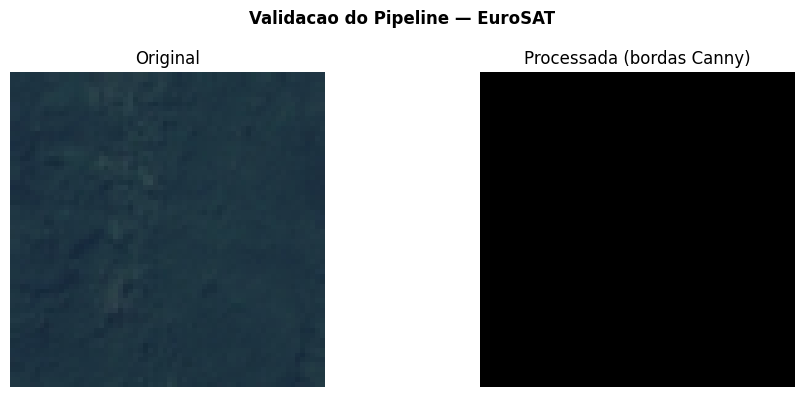

Pipeline validado


In [ ]:
#VALIDACAO DO PIPELINE
#TESTE COM UMA UNICA IMAGEM

import shutil
shutil.rmtree(pasta_saida, ignore_errors=True)
os.makedirs(pasta_saida, exist_ok=True)

imagem_teste = lista_de_caminhos[0]
resultado_teste = processar_imagem(imagem_teste)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

img_original = cv2.imread(imagem_teste)
img_original_rgb = cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB)
img_processada = cv2.imread(resultado_teste, cv2.IMREAD_GRAYSCALE)

ax1.imshow(img_original_rgb)
ax1.set_title('Original')
ax1.axis('off')

ax2.imshow(img_processada, cmap='gray')
ax2.set_title('Processada (bordas Canny)')
ax2.axis('off')

plt.suptitle('Validacao do Pipeline — EuroSAT', fontweight='bold')
plt.tight_layout()
plt.savefig('validacao_pipeline.png', dpi=150, bbox_inches='tight')
plt.show()
print('Pipeline validado')

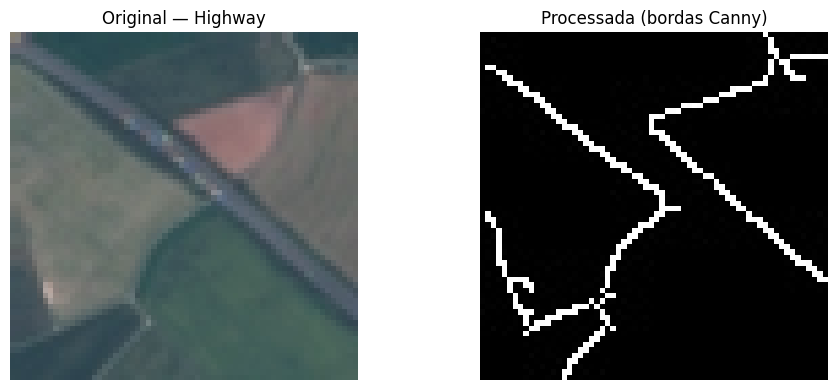

In [ ]:
#TESTE COM IMG DE BORDA MAIS VISIVEL
imagem_teste2 = random.choice(caminhos_por_classe['Highway'])
resultado_teste2 = processar_imagem(imagem_teste2)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.imshow(cv2.cvtColor(cv2.imread(imagem_teste2), cv2.COLOR_BGR2RGB))
ax1.set_title('Original — Highway')
ax1.axis('off')
ax2.imshow(cv2.imread(resultado_teste2, cv2.IMREAD_GRAYSCALE), cmap='gray')
ax2.set_title('Processada (bordas Canny)')
ax2.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
#EXECUCAO SEQUENCIAL

shutil.rmtree(pasta_saida, ignore_errors=True)
os.makedirs(pasta_saida, exist_ok=True)

print('Iniciando execucao sequencial')
print(f'Total de imagens: {len(lista_de_caminhos)}')
print('-' * 50)

inicio_baseline = time.time()

resultados_seq = []
erros = 0

for i, caminho in enumerate(lista_de_caminhos):
    resultado = processar_imagem(caminho)
    if resultado:
        resultados_seq.append(resultado)
    else:
        erros += 1

    #PROGRESSO A CADA 400 IMGS
    if (i + 1) % 400 == 0:
        tempo_parcial = time.time() - inicio_baseline
        print(f'  [{i+1}/{len(lista_de_caminhos)}] '
              f'Tempo parcial: {tempo_parcial:.2f}s | '
              f'Throughput: {(i+1)/tempo_parcial:.1f} img/s')

fim_baseline = time.time()
tempo_baseline = fim_baseline - inicio_baseline
throughput_baseline = len(resultados_seq) / tempo_baseline

print('-' * 50)
print(f'\nExecucao sequencial concluida')
print(f'  Imagens processadas : {len(resultados_seq)}')
print(f'  Erros               : {erros}')
print(f'  Tempo total         : {tempo_baseline:.4f} s')
print(f'  Throughput baseline : {throughput_baseline:.2f} img/s')
print(f'  Speedup (referencia): 1.0x')

Iniciando execucao sequencial
Total de imagens: 2000
--------------------------------------------------
  [400/2000] Tempo parcial: 0.26s | Throughput: 1540.7 img/s
  [800/2000] Tempo parcial: 0.49s | Throughput: 1639.9 img/s
  [1200/2000] Tempo parcial: 0.80s | Throughput: 1495.5 img/s
  [1600/2000] Tempo parcial: 1.10s | Throughput: 1451.3 img/s
  [2000/2000] Tempo parcial: 1.30s | Throughput: 1540.6 img/s
--------------------------------------------------

Execucao sequencial concluida
  Imagens processadas : 2000
  Erros               : 0
  Tempo total         : 1.2985 s
  Throughput baseline : 1540.27 img/s
  Speedup (referencia): 1.0x


In [ ]:
#TABELA DE RESULTADOS DA FASE 2

resultados_df = pd.DataFrame([
    {
        'Configuracao'  : 'Sequencial',
        'N Processos'   : 1,
        'Tempo (s)'     : round(tempo_baseline, 4),
        'Speedup'       : 1.0,
        'Eficiencia'    : 1.0
    }
])

print('=== TABELA DE RESULTADOS — FASE 2 (BASELINE) ===')
print(resultados_df.to_string(index=False))

resultados_df.to_csv('resultados.csv', index=False)
print('\nResultados salvos em resultados.csv')
print(f'\nIMPORTANTE: tempo_baseline = {tempo_baseline:.4f}s')

=== TABELA DE RESULTADOS — FASE 2 (BASELINE) ===
Configuracao  N Processos  Tempo (s)  Speedup  Eficiencia
  Sequencial            1     1.2985      1.0         1.0

Resultados salvos em resultados.csv

IMPORTANTE: tempo_baseline = 1.2985s


#FASE 3 — Execução com Multiprocessing

Utilizar multiprocessing.Pool para distribuir as imagens entre múltiplos processos.

Para cada configuração (2, 4, 6 e 8 processos) medir:
- Tempo total de processamento
- Speedup = tempo_baseline / tempo_paralelo
- Eficiência = speedup / número_de_processos


In [ ]:
import shutil

resultados_multiprocessing = []  #ACUMULA RESULTADOS DE CADA CONFIGURACAO

for n_processos in [2, 4, 6, 8]:
    shutil.rmtree(pasta_saida, ignore_errors=True)
    os.makedirs(pasta_saida, exist_ok=True)

    print(f'Testando com {n_processos} processos...')

    inicio = time.time()

    with Pool(processes=n_processos) as pool:
        resultados = pool.map(processar_imagem, lista_de_caminhos)

    fim = time.time()
    tempo = fim - inicio

    #CALCULAR METRICAS
    speedup    = tempo_baseline / tempo
    eficiencia = speedup / n_processos
    throughput = len(lista_de_caminhos) / tempo

    resultados_multiprocessing.append({
        'Configuracao' : 'Multiprocessing',
        'N Processos'  : n_processos,
        'Tempo (s)'    : round(tempo, 4),
        'Speedup'      : round(speedup, 4),
        'Eficiencia'   : round(eficiencia, 4)
    })

    print(f'  Tempo      : {tempo:.4f} s')
    print(f'  Throughput : {throughput:.2f} img/s')
    print(f'  Speedup    : {speedup:.4f}x')
    print(f'  Eficiencia : {eficiencia:.4f}')
    print()

print('Fase 3 concluida')

Testando com 2 processos...
  Tempo      : 0.9232 s
  Throughput : 2166.33 img/s
  Speedup    : 1.4065x
  Eficiencia : 0.7032

Testando com 4 processos...
  Tempo      : 0.8872 s
  Throughput : 2254.34 img/s
  Speedup    : 1.4636x
  Eficiencia : 0.3659

Testando com 6 processos...
  Tempo      : 0.5513 s
  Throughput : 3627.60 img/s
  Speedup    : 2.3552x
  Eficiencia : 0.3925

Testando com 8 processos...
  Tempo      : 0.5903 s
  Throughput : 3388.20 img/s
  Speedup    : 2.1997x
  Eficiencia : 0.2750

Fase 3 concluida


In [ ]:
#TABELA COMPLETA DE RESULTADOS (fase 2 + fase 3)

linha_baseline = pd.DataFrame([{
    'Configuracao' : 'Sequencial',
    'N Processos'  : 1,
    'Tempo (s)'    : round(tempo_baseline, 4),
    'Speedup'      : 1.0,
    'Eficiencia'   : 1.0
}])

df_multi = pd.DataFrame(resultados_multiprocessing)
tabela_completa = pd.concat([linha_baseline, df_multi], ignore_index=True)

print('=== TABELA DE RESULTADOS — FASES 2 e 3 ===')
print(tabela_completa.to_string(index=False))

tabela_completa.to_csv('resultados.csv', index=False)
print('\nResultados salvos em resultados.csv')

=== TABELA DE RESULTADOS — FASES 2 e 3 ===
   Configuracao  N Processos  Tempo (s)  Speedup  Eficiencia
     Sequencial            1     1.2985   1.0000      1.0000
Multiprocessing            2     0.9232   1.4065      0.7032
Multiprocessing            4     0.8872   1.4636      0.3659
Multiprocessing            6     0.5513   2.3552      0.3925
Multiprocessing            8     0.5903   2.1997      0.2750

Resultados salvos em resultados.csv


Descricao dos graficos:
1. Tempo total x numero de processos
2. Speedup x numero de processos (com linha do speedup ideal)
3. Eficiencia x numero de processos

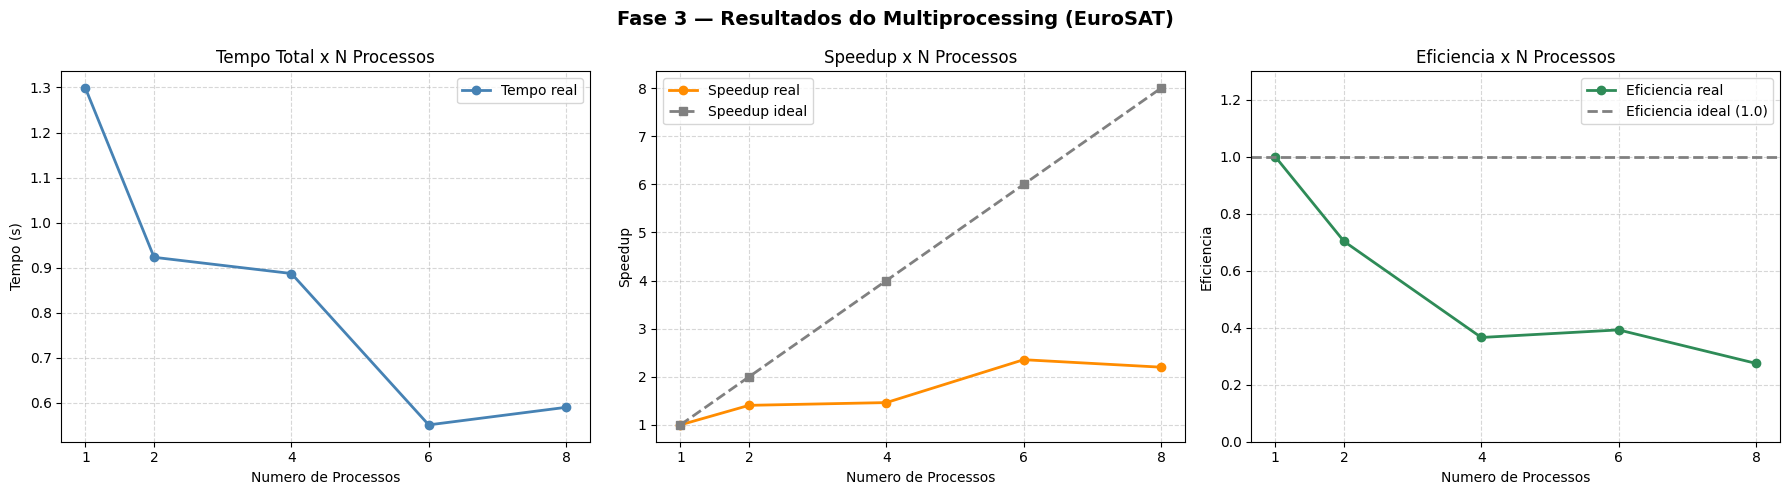

Graficos salvos em graficos_fase3.png


In [ ]:
#GRAFICOS FASE 3

n_proc      = tabela_completa['N Processos'].tolist()
tempos      = tabela_completa['Tempo (s)'].tolist()
speedups    = tabela_completa['Speedup'].tolist()
eficiencias = tabela_completa['Eficiencia'].tolist()
ideal       = n_proc  #SPEEDUP IDEAIS = N

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Fase 3 — Resultados do Multiprocessing (EuroSAT)', fontsize=14, fontweight='bold')

#GRAFICO 1
axes[0].plot(n_proc, tempos, marker='o', color='steelblue', linewidth=2, label='Tempo real')
axes[0].set_title('Tempo Total x N Processos')
axes[0].set_xlabel('Numero de Processos')
axes[0].set_ylabel('Tempo (s)')
axes[0].set_xticks(n_proc)
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].legend()

#GRAFICO 2
axes[1].plot(n_proc, speedups, marker='o', color='darkorange', linewidth=2, label='Speedup real')
axes[1].plot(n_proc, ideal,   marker='s', color='gray', linewidth=2, linestyle='--', label='Speedup ideal')
axes[1].set_title('Speedup x N Processos')
axes[1].set_xlabel('Numero de Processos')
axes[1].set_ylabel('Speedup')
axes[1].set_xticks(n_proc)
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].legend()

#GRAFICO 3
axes[2].plot(n_proc, eficiencias, marker='o', color='seagreen', linewidth=2, label='Eficiencia real')
axes[2].axhline(y=1.0, color='gray', linestyle='--', linewidth=2, label='Eficiencia ideal (1.0)')
axes[2].set_title('Eficiencia x N Processos')
axes[2].set_xlabel('Numero de Processos')
axes[2].set_ylabel('Eficiencia')
axes[2].set_xticks(n_proc)
axes[2].set_ylim(0, 1.3)
axes[2].grid(True, linestyle='--', alpha=0.5)
axes[2].legend()

plt.tight_layout()
plt.savefig('graficos_fase3.png', dpi=150, bbox_inches='tight')
plt.show()
print('Graficos salvos em graficos_fase3.png')

# FASE 4 — Comparação com Vetorização (NumPy)

Implementar uma versão vetorizada do pipeline, processando todas as imagens de uma vez como um array 4D `(N, H, W, C)` usando operações NumPy puras.

Comparamos o tempo com o baseline sequencial e o melhor resultado do multiprocessing.

**Limitação da vetorização:** O filtro Gaussiano e o Canny do OpenCV não operam nativamente em arrays 4D, então precisa simular essas operações com NumPy:
- Escala de cinza: média ponderada dos canais RGB
- Suavização: convolução manual com kernel Gaussiano
- Bordas: gradiente de Sobel como aproximação do Canny

In [ ]:
#FASE 4 — VERSAO VETORIZADA COM NUMPY
#PROCESSA TODAS AS IMAGENS COMO UM ARRAY 4D (N, H, W, C)


from scipy.ndimage import gaussian_filter

print('Iniciando versao vetorizada...')
print(f'Carregando {len(lista_de_caminhos)} imagens para memoria...')

inicio_vetorizado = time.time()

#LEITURA E MONTAGEM DO ARRAY
#CARREGA TODAS AS IMAGENS DE UMA VEZ EM MEMORIA
imagens_lista = []
for caminho in lista_de_caminhos:
    img = cv2.imread(caminho)
    if img is not None:
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        imagens_lista.append(img_rgb)

#N IMAGENS DE H x W PIXELS COM C CANAIS
batch = np.array(imagens_lista, dtype=np.float32)  #SHAPE: (2000, 64, 64, 3)
print(f'Array 4D criado: shape={batch.shape}, dtype={batch.dtype}')
print(f'Memoria ocupada: {batch.nbytes / 1024**2:.1f} MB')

#CONVERSAO PARA ESCALA DE CINZA VETORIZADA
pesos = np.array([0.299, 0.587, 0.114], dtype=np.float32)  # R, G, B
cinza_batch = np.dot(batch, pesos)  # shape: (2000, 64, 64)

#FILTRO GAUSSIANO
borrado_batch = np.zeros_like(cinza_batch)
for i in range(len(cinza_batch)):
    borrado_batch[i] = gaussian_filter(cinza_batch[i], sigma=1.0)

#DETECCAO DE BORDAS COM GRADIENTE DE SOBEL
kernel_x = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=np.float32)
kernel_y = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=np.float32)

from scipy.ndimage import convolve
bordas_batch = np.zeros_like(borrado_batch)
for i in range(len(borrado_batch)):
    gx = convolve(borrado_batch[i], kernel_x)
    gy = convolve(borrado_batch[i], kernel_y)
    magnitude = np.sqrt(gx**2 + gy**2)
    bordas_batch[i] = np.where(magnitude > 100, 255, 0)

#SALVAMENTO
pasta_saida_vet = 'imagens_vetorizadas'
os.makedirs(pasta_saida_vet, exist_ok=True)

for i, caminho in enumerate(lista_de_caminhos[:len(bordas_batch)]):
    nome_arquivo = os.path.basename(caminho)
    caminho_saida = os.path.join(pasta_saida_vet, nome_arquivo)
    cv2.imwrite(caminho_saida, bordas_batch[i].astype(np.uint8))

fim_vetorizado = time.time()
tempo_vetorizado = fim_vetorizado - inicio_vetorizado
throughput_vetorizado = len(lista_de_caminhos) / tempo_vetorizado
speedup_vetorizado = tempo_baseline / tempo_vetorizado

print()
print('Versao vetorizada concluida!')
print(f'  Tempo total : {tempo_vetorizado:.4f} s')
print(f'  Throughput  : {throughput_vetorizado:.2f} img/s')
print(f'  Speedup     : {speedup_vetorizado:.4f}x (em relacao ao baseline)')

Iniciando versao vetorizada...
Carregando 2000 imagens para memoria...
Array 4D criado: shape=(2000, 64, 64, 3), dtype=float32
Memoria ocupada: 93.8 MB

Versao vetorizada concluida!
  Tempo total : 1.2498 s
  Throughput  : 1600.30 img/s
  Speedup     : 1.0390x (em relacao ao baseline)


In [ ]:
#TABELA FINAL COMPARATIVA - FASES 2, 3 e 4

linha_vetorizado = pd.DataFrame([{
    'Configuracao' : 'Vetorizado (NumPy)',
    'N Processos'  : '-',
    'Tempo (s)'    : round(tempo_vetorizado, 4),
    'Speedup'      : round(speedup_vetorizado, 4),
    'Eficiencia'   : '-'
}])

tabela_final = pd.concat([tabela_completa, linha_vetorizado], ignore_index=True)

print('=== TABELA FINAL COMPARATIVA — FASES 2, 3 e 4 ===')
print(tabela_final.to_string(index=False))

tabela_final.to_csv('resultados_final.csv', index=False)
print('\nResultados salvos em resultados_final.csv')

=== TABELA FINAL COMPARATIVA — FASES 2, 3 e 4 ===
      Configuracao N Processos  Tempo (s)  Speedup Eficiencia
        Sequencial           1     1.2985   1.0000        1.0
   Multiprocessing           2     0.9232   1.4065     0.7032
   Multiprocessing           4     0.8872   1.4636     0.3659
   Multiprocessing           6     0.5513   2.3552     0.3925
   Multiprocessing           8     0.5903   2.1997      0.275
Vetorizado (NumPy)           -     1.2498   1.0390          -

Resultados salvos em resultados_final.csv


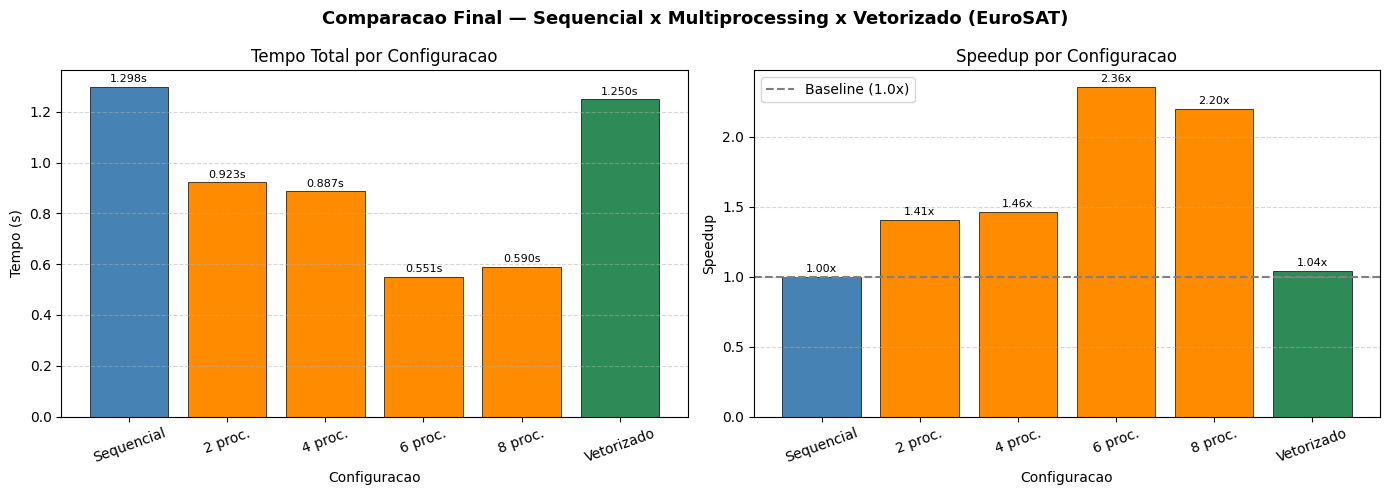

Grafico salvo em comparacao_final.png


In [ ]:
#GRAFICO COMPARATIVO FINAL: SEQUENCIAL x MULTIPROCESSING x VETORIZADO

configs   = ['Sequencial', '2 proc.', '4 proc.', '6 proc.', '8 proc.', 'Vetorizado']
tempos_todos   = ([tempo_baseline]
                  + [r['Tempo (s)'] for r in resultados_multiprocessing]
                  + [tempo_vetorizado])
speedups_todos = ([1.0]
                  + [r['Speedup'] for r in resultados_multiprocessing]
                  + [speedup_vetorizado])

cores = ['steelblue', 'darkorange', 'darkorange', 'darkorange', 'darkorange', 'seagreen']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Comparacao Final — Sequencial x Multiprocessing x Vetorizado (EuroSAT)',
             fontsize=13, fontweight='bold')

#GRAFICO DE TEMPO
bars1 = ax1.bar(configs, tempos_todos, color=cores, edgecolor='black', linewidth=0.5)
ax1.set_title('Tempo Total por Configuracao')
ax1.set_ylabel('Tempo (s)')
ax1.set_xlabel('Configuracao')
ax1.tick_params(axis='x', rotation=20)
ax1.grid(True, axis='y', linestyle='--', alpha=0.5)
for bar, val in zip(bars1, tempos_todos):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.3f}s', ha='center', va='bottom', fontsize=8)

#GRAFICO DE SPEEDUP
bars2 = ax2.bar(configs, speedups_todos, color=cores, edgecolor='black', linewidth=0.5)
ax2.axhline(y=1.0, color='gray', linestyle='--', linewidth=1.5, label='Baseline (1.0x)')
ax2.set_title('Speedup por Configuracao')
ax2.set_ylabel('Speedup')
ax2.set_xlabel('Configuracao')
ax2.tick_params(axis='x', rotation=20)
ax2.grid(True, axis='y', linestyle='--', alpha=0.5)
ax2.legend()
for bar, val in zip(bars2, speedups_todos):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{val:.2f}x', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('comparacao_final.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafico salvo em comparacao_final.png')